Discover oMEGACat-BH-2

In [ ]:
#import needed packages
from multiprocessing import Pool
import numpy as np
from astropy import units as u

from astropy.table import Table
from periapsis.data.common import AstrometryData
from periapsis.prior.uniform_prior import UniformPrior
from periapsis.prior.normal_prior import NormalPrior
from periapsis.fitting.mcmcCampbell import MCMCCampbell
from periapsis.fitting.ultranestlinear import UltranestLinearFitter
from periapsis.stats import stat_funcs
from periapsis.plotting import plots 


Load in the data table from Whitaker et al. (2026)

In [2]:
data_table = Table.read("/uufs/astro.utah.edu/common/home/u1383373/periapsis/synthetic_data/apjlae7a5ct1_mrt.txt",
                format="ascii.mrt")

clean= ~(data_table['Flag'] > 0)

t = np.asarray(data_table['Year'])[clean]
x = np.asarray(data_table['DeltaRA'])[clean]
y = np.asarray(data_table['DeltaDec'])[clean]
x_err = np.asarray(data_table['e_DeltaRA'])[clean]
y_err = np.asarray(data_table['e_DeltaDec'])[clean]
ref_epoch = 2012
m_vis = 0.78 #solar masses



Let's perform our analysis in AU at the distance of Omega Centauri

In [3]:
dist = 5494 #pc
def mas_to_AU(r):
    return r/1000 * (dist * np.pi)/(180*3600) *206265


x = mas_to_AU(x)
y = mas_to_AU(y)
x_err = mas_to_AU(x_err)
y_err = mas_to_AU(y_err)

Use the package to intialize the data for fitting

In [4]:
fit_data = AstrometryData(t, x, y, x_err, y_err, ref_epoch)

Create your priors, here we will use the physical Campbell elements to describe the orbit. 

In [5]:
priors = {
    'P': UniformPrior(1, 200),  # Period in years
    'a': UniformPrior(1, 100),  # Semi-major axis in AU
    'e': UniformPrior(0, 0.95),  # Eccentricity
    'cosi': UniformPrior(-1, 1),  # cos(Inclination) 
    'Omega': UniformPrior(0, 2*np.pi),  # Longitude of ascending node
    'omega': UniformPrior(0, 2*np.pi),  # Argument of periastron 
    't0': UniformPrior(-0.5,0.5), # Time of periastron passage in fraction of period
    'dx': UniformPrior(-10, 10),  # Offset in x (RA) in AU
    'dy': UniformPrior(-10, 10),  # Offset in y (Dec) in AU
    'dpmra': UniformPrior(-10,10),  # Proper motion in RA in AU/yr with a normal prior
    'dpmdec': UniformPrior(-10,10),  # Proper motion in Dec in AU/yr with a normal prior

}

We now have everything needed to get an orbital fit, first we will sample the Campbell elements and the other orbital parameters with mcmc

In [6]:
with Pool(processes=4) as pool:
    fitter = MCMCCampbell(nwalkers=32, niter=1000, m1=m_vis,m2_max=50, pool=pool, **priors)
    results = fitter.fit(fit_data)

100%|██████████| 1000/1000 [00:06<00:00, 144.20it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 11 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [99.0059934  90.12546867 92.70275132 62.1537689  65.01572365 75.07298096
 75.04227565 72.4433423  70.61782772 69.50732313 70.95412624]


In [7]:
stats,fit_results = stat_funcs.all_stats(results,data=fit_data)

{
    "credible_intervals": {
        "M2": {
            "+1sigma": 5.761528095453483,
            "+2sigma": 7.200009629020265,
            "-1sigma": 4.24403290027432,
            "-2sigma": 3.649490647690963
        },
        "Omega": {
            "+1sigma": 5.027952185856581,
            "+2sigma": 5.068891640682939,
            "-1sigma": 4.9360634382769355,
            "-2sigma": 4.897636813603611
        },
        "P": {
            "+1sigma": 144.21431182947168,
            "+2sigma": 163.78526884760728,
            "-1sigma": 100.71001145045723,
            "-2sigma": 89.85599162501383
        },
        "a": {
            "+1sigma": 44.30960224563525,
            "+2sigma": 49.51271517042886,
            "-1sigma": 32.98184584360334,
            "-2sigma": 29.161042810003803
        },
        "cosi": {
            "+1sigma": -0.38140646412813567,
            "+2sigma": -0.35298586198685955,
            "-1sigma": -0.44301229335166575,
            "-2sigma": -0.4670900460

/uufs/astro.utah.edu/common/home/u1383373/periapsis/src/periapsis/plotting/plots.py:88: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 640x480 with 1 Axes>,
 <Figure size 2440x2440 with 121 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 1100x1680 with 12 Axes>,
 <Figure size 640x480 with 3 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>)

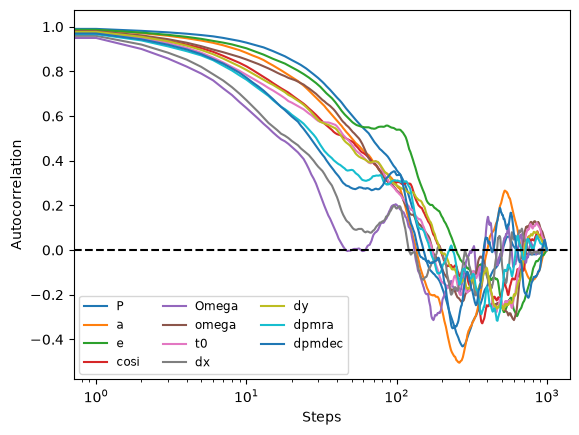

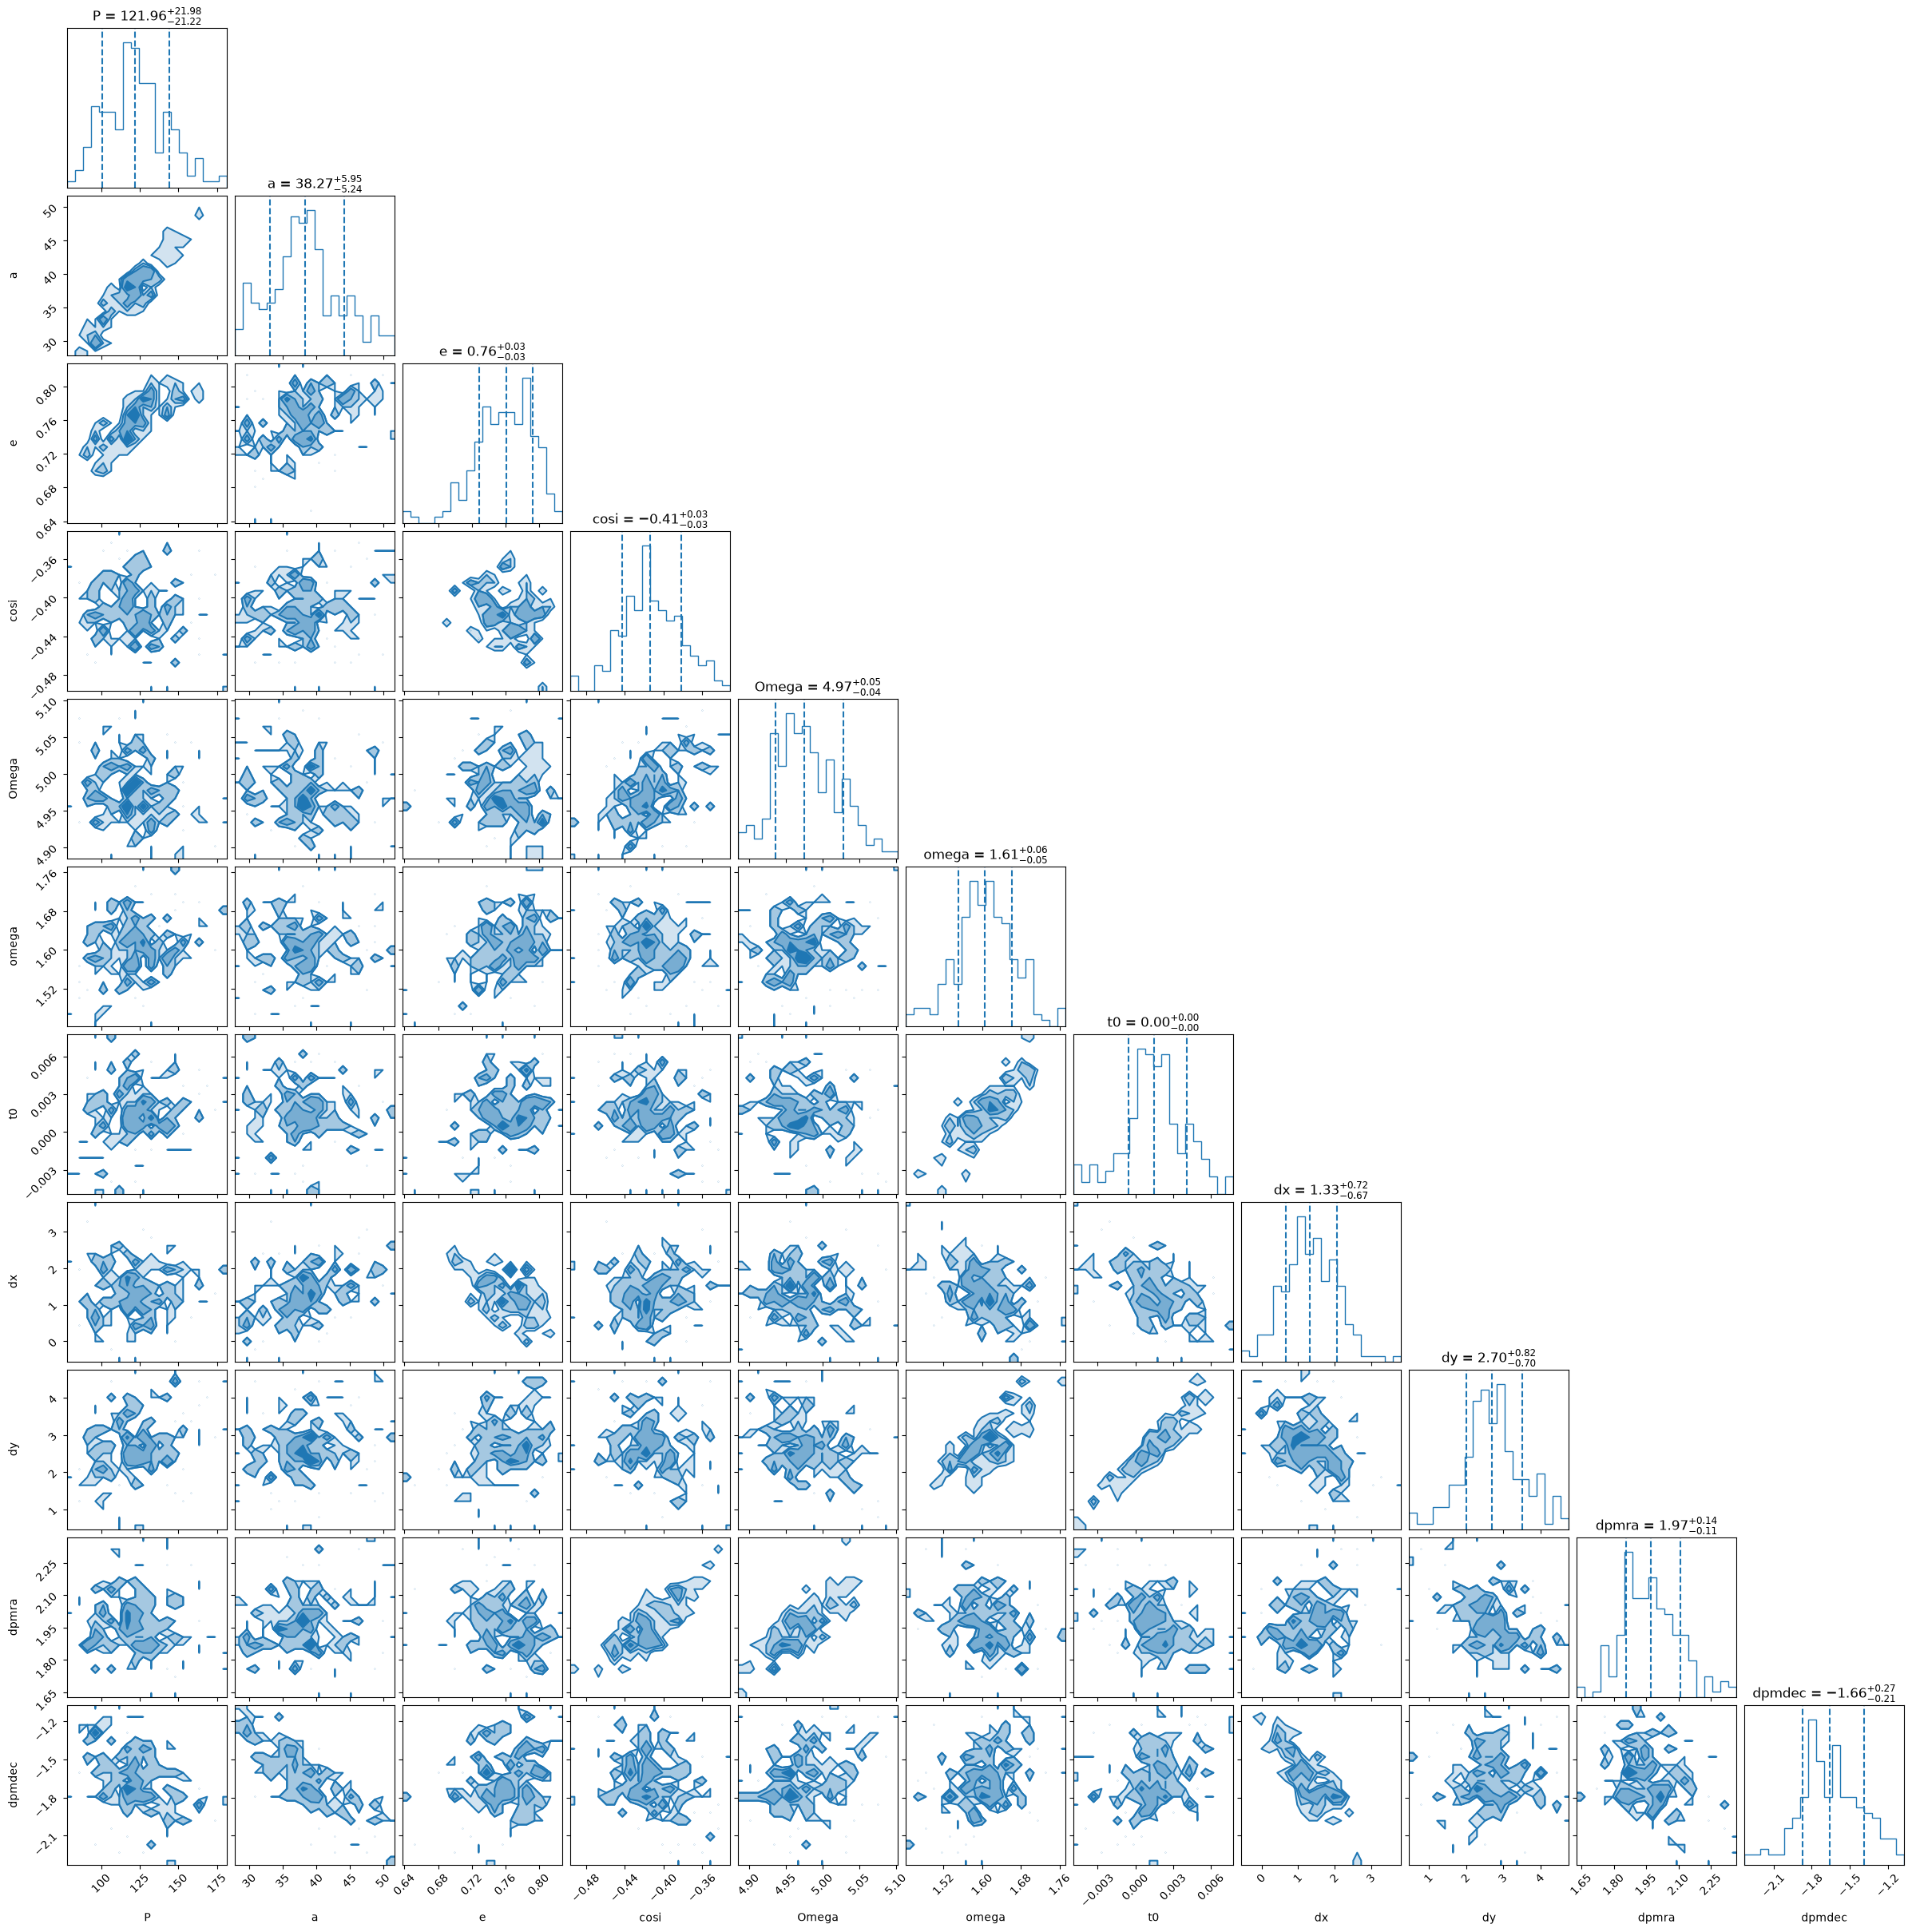

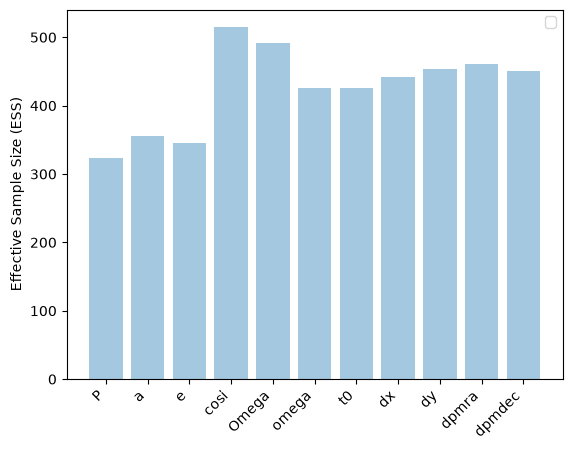

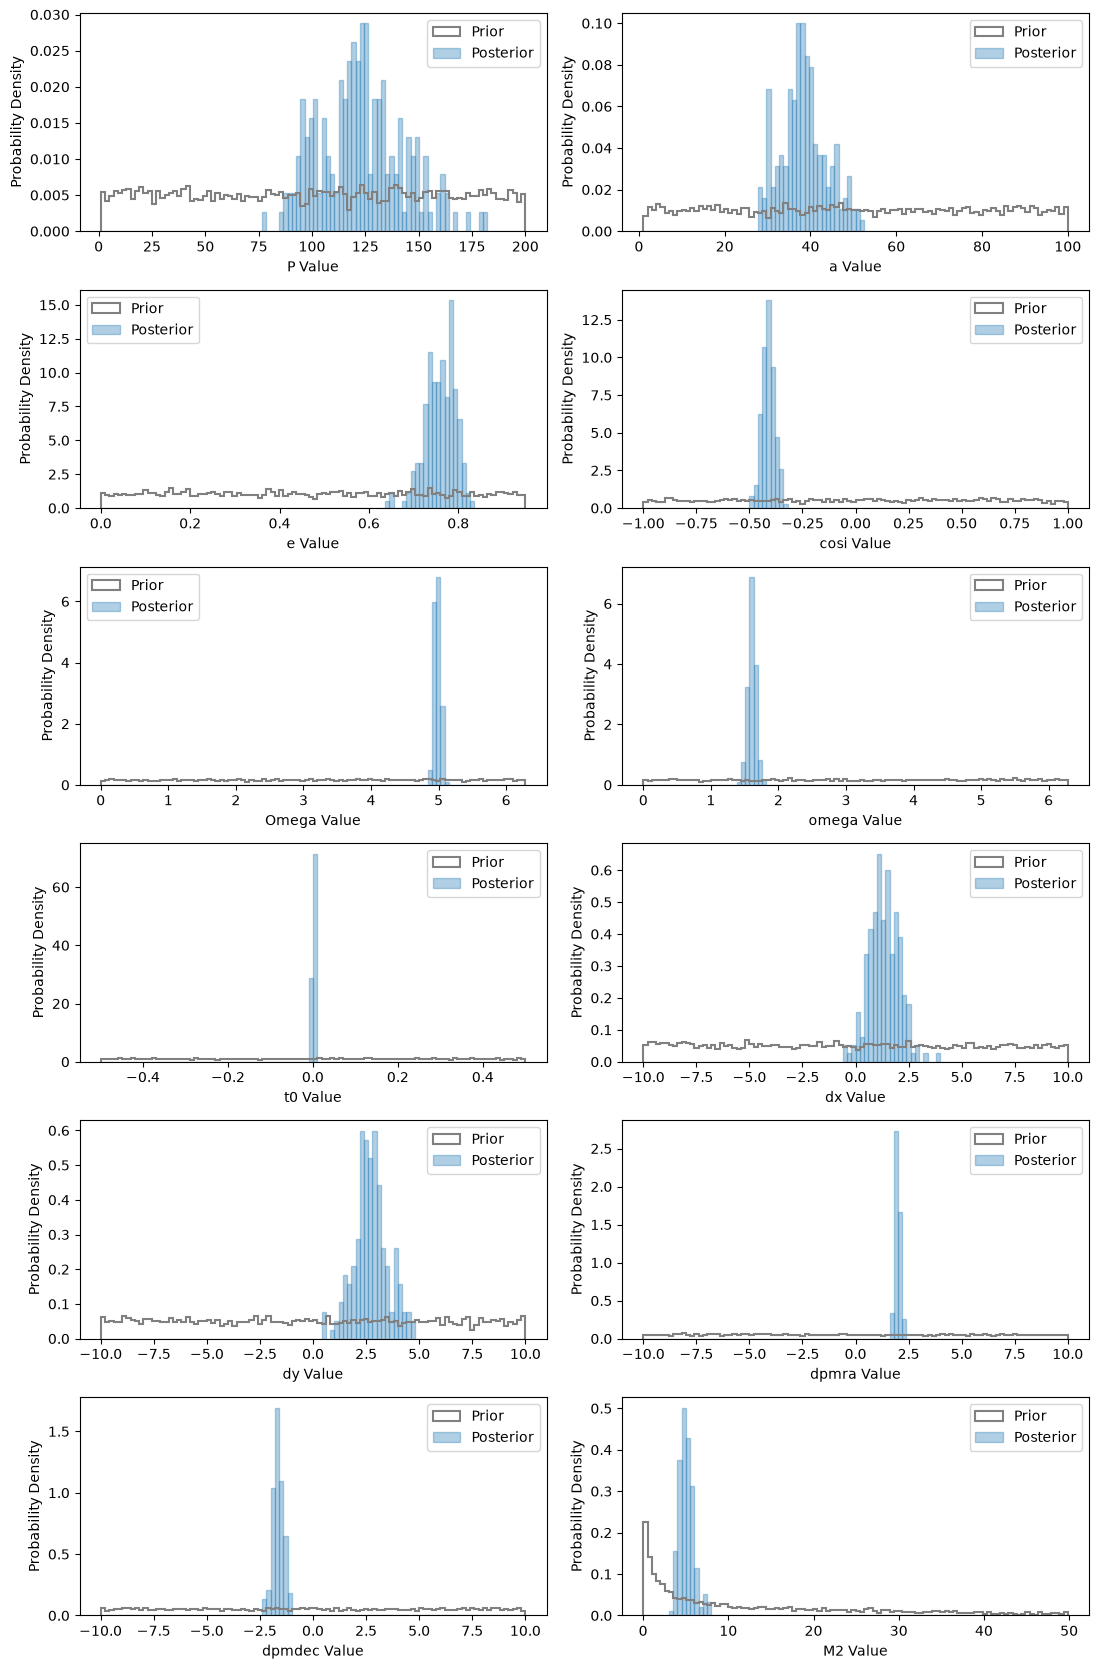

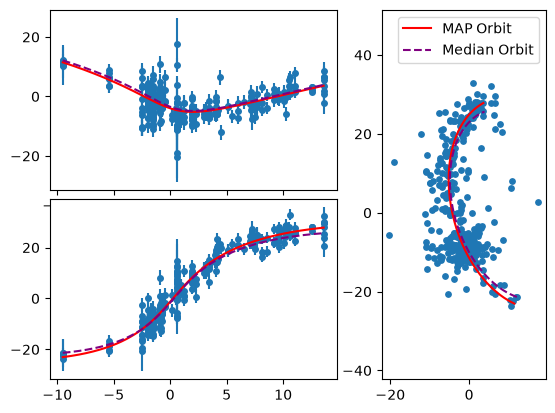

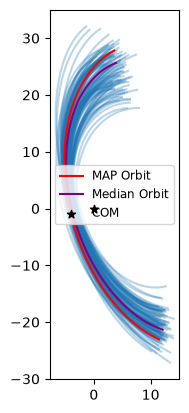

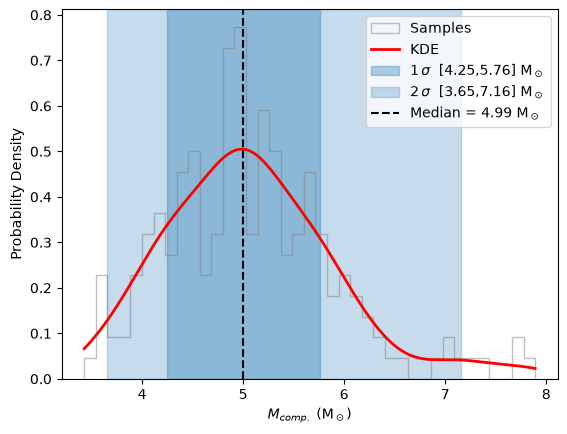

In [8]:
plots.all_plots(results=results,data=fit_data,priors=priors,m1=m_vis)

The package offers multiple models and samplers. Here we can try linear least squares with the Thiele Innes coefficients and sample P,e and t0 with Ultranest

In [ ]:
fitter2 = UltranestLinearFitter(nlive=6000,min_ess=1000,m1=m_vis,m2_max=50,**priors)
results2 = fitter2.fit(fit_data)

In [ ]:
stats2,fits_results2 = stat_funcs.all_stats(results2,data=fit_data)

{
    "credible_intervals": {
        "A": {
            "+1sigma": -7.887654528144796,
            "+2sigma": -5.7941888096143215,
            "-1sigma": -17.6450270330106,
            "-2sigma": -21.314501241666164
        },
        "B": {
            "+1sigma": -0.8245180027565764,
            "+2sigma": 0.8439003283169331,
            "-1sigma": -5.027431539269226,
            "-2sigma": -8.650262135077016
        },
        "F": {
            "+1sigma": -4.891319547095293,
            "+2sigma": -3.420613567343683,
            "-1sigma": -11.378943232614922,
            "-2sigma": -15.636276926792595
        },
        "G": {
            "+1sigma": 43.64850230874326,
            "+2sigma": 54.42414864541378,
            "-1sigma": 16.866135218149843,
            "-2sigma": 11.455208874757712
        },
        "M2": {
            "+1sigma": 5.6894233779553085,
            "+2sigma": 7.337647100573013,
            "-1sigma": 3.415309208981867,
            "-2sigma": 2.716184521665

(<Figure size 1100x1680 with 12 Axes>,
 <Figure size 2440x2440 with 121 Axes>,
 <Figure size 640x480 with 3 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>)

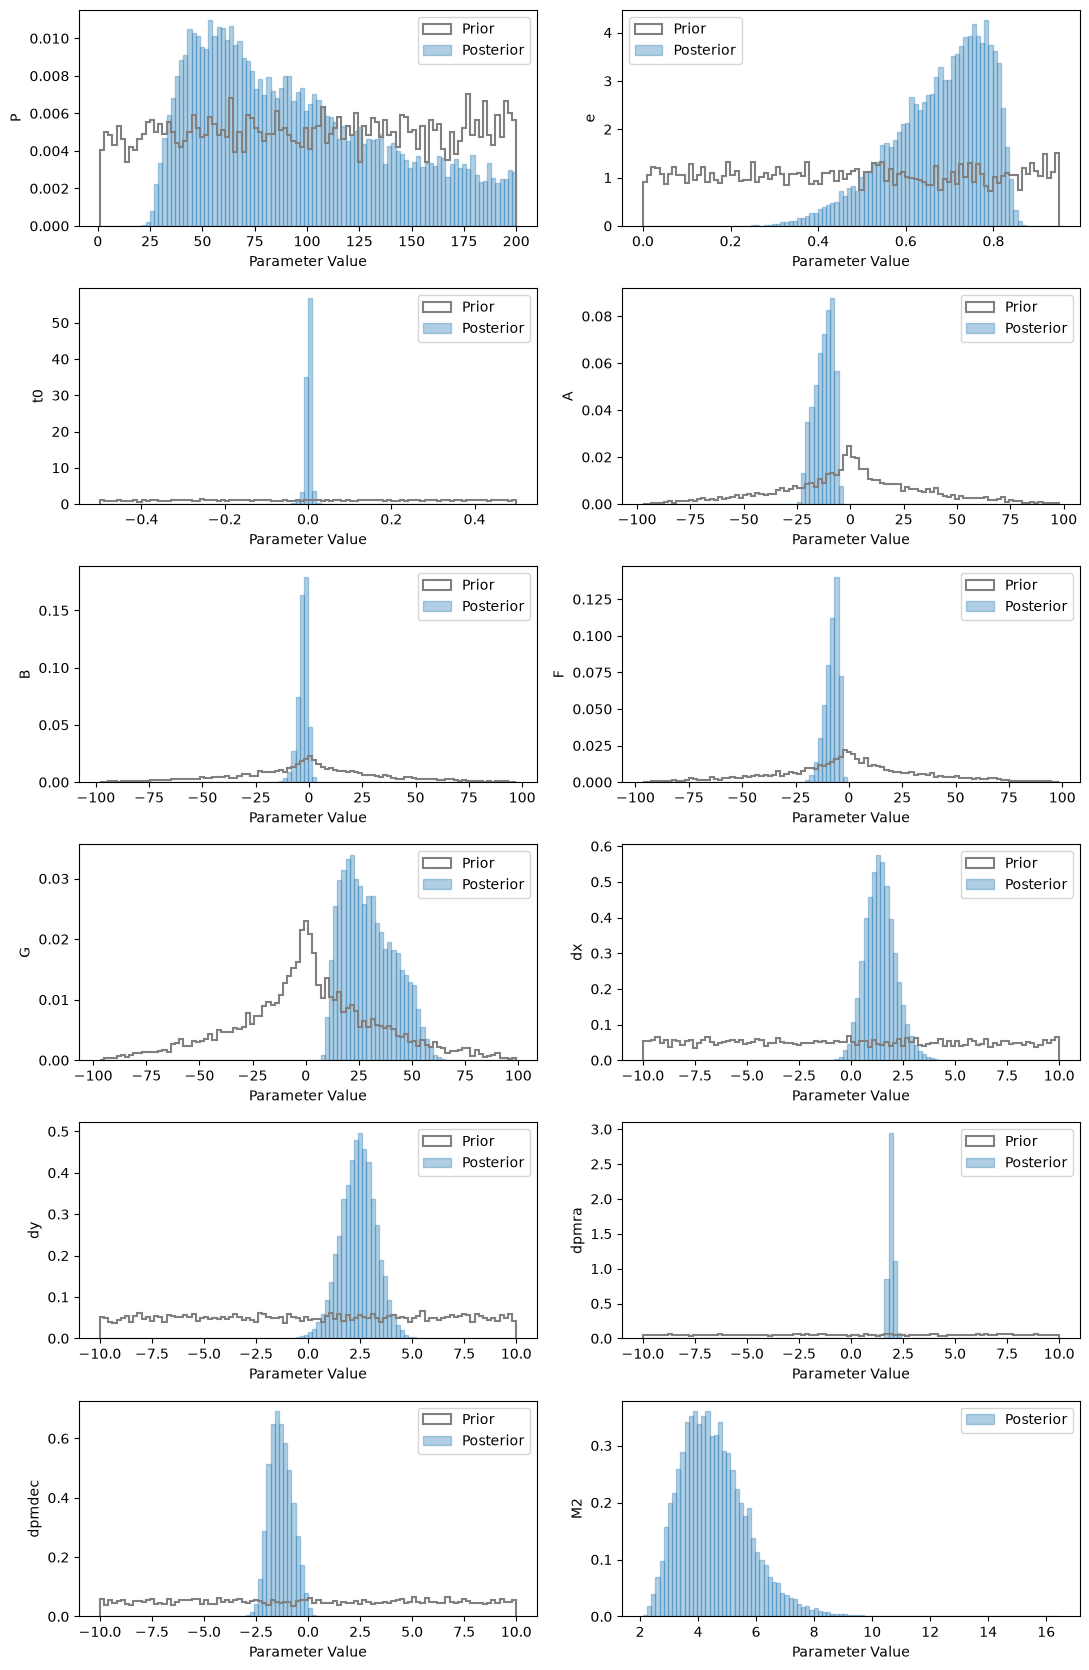

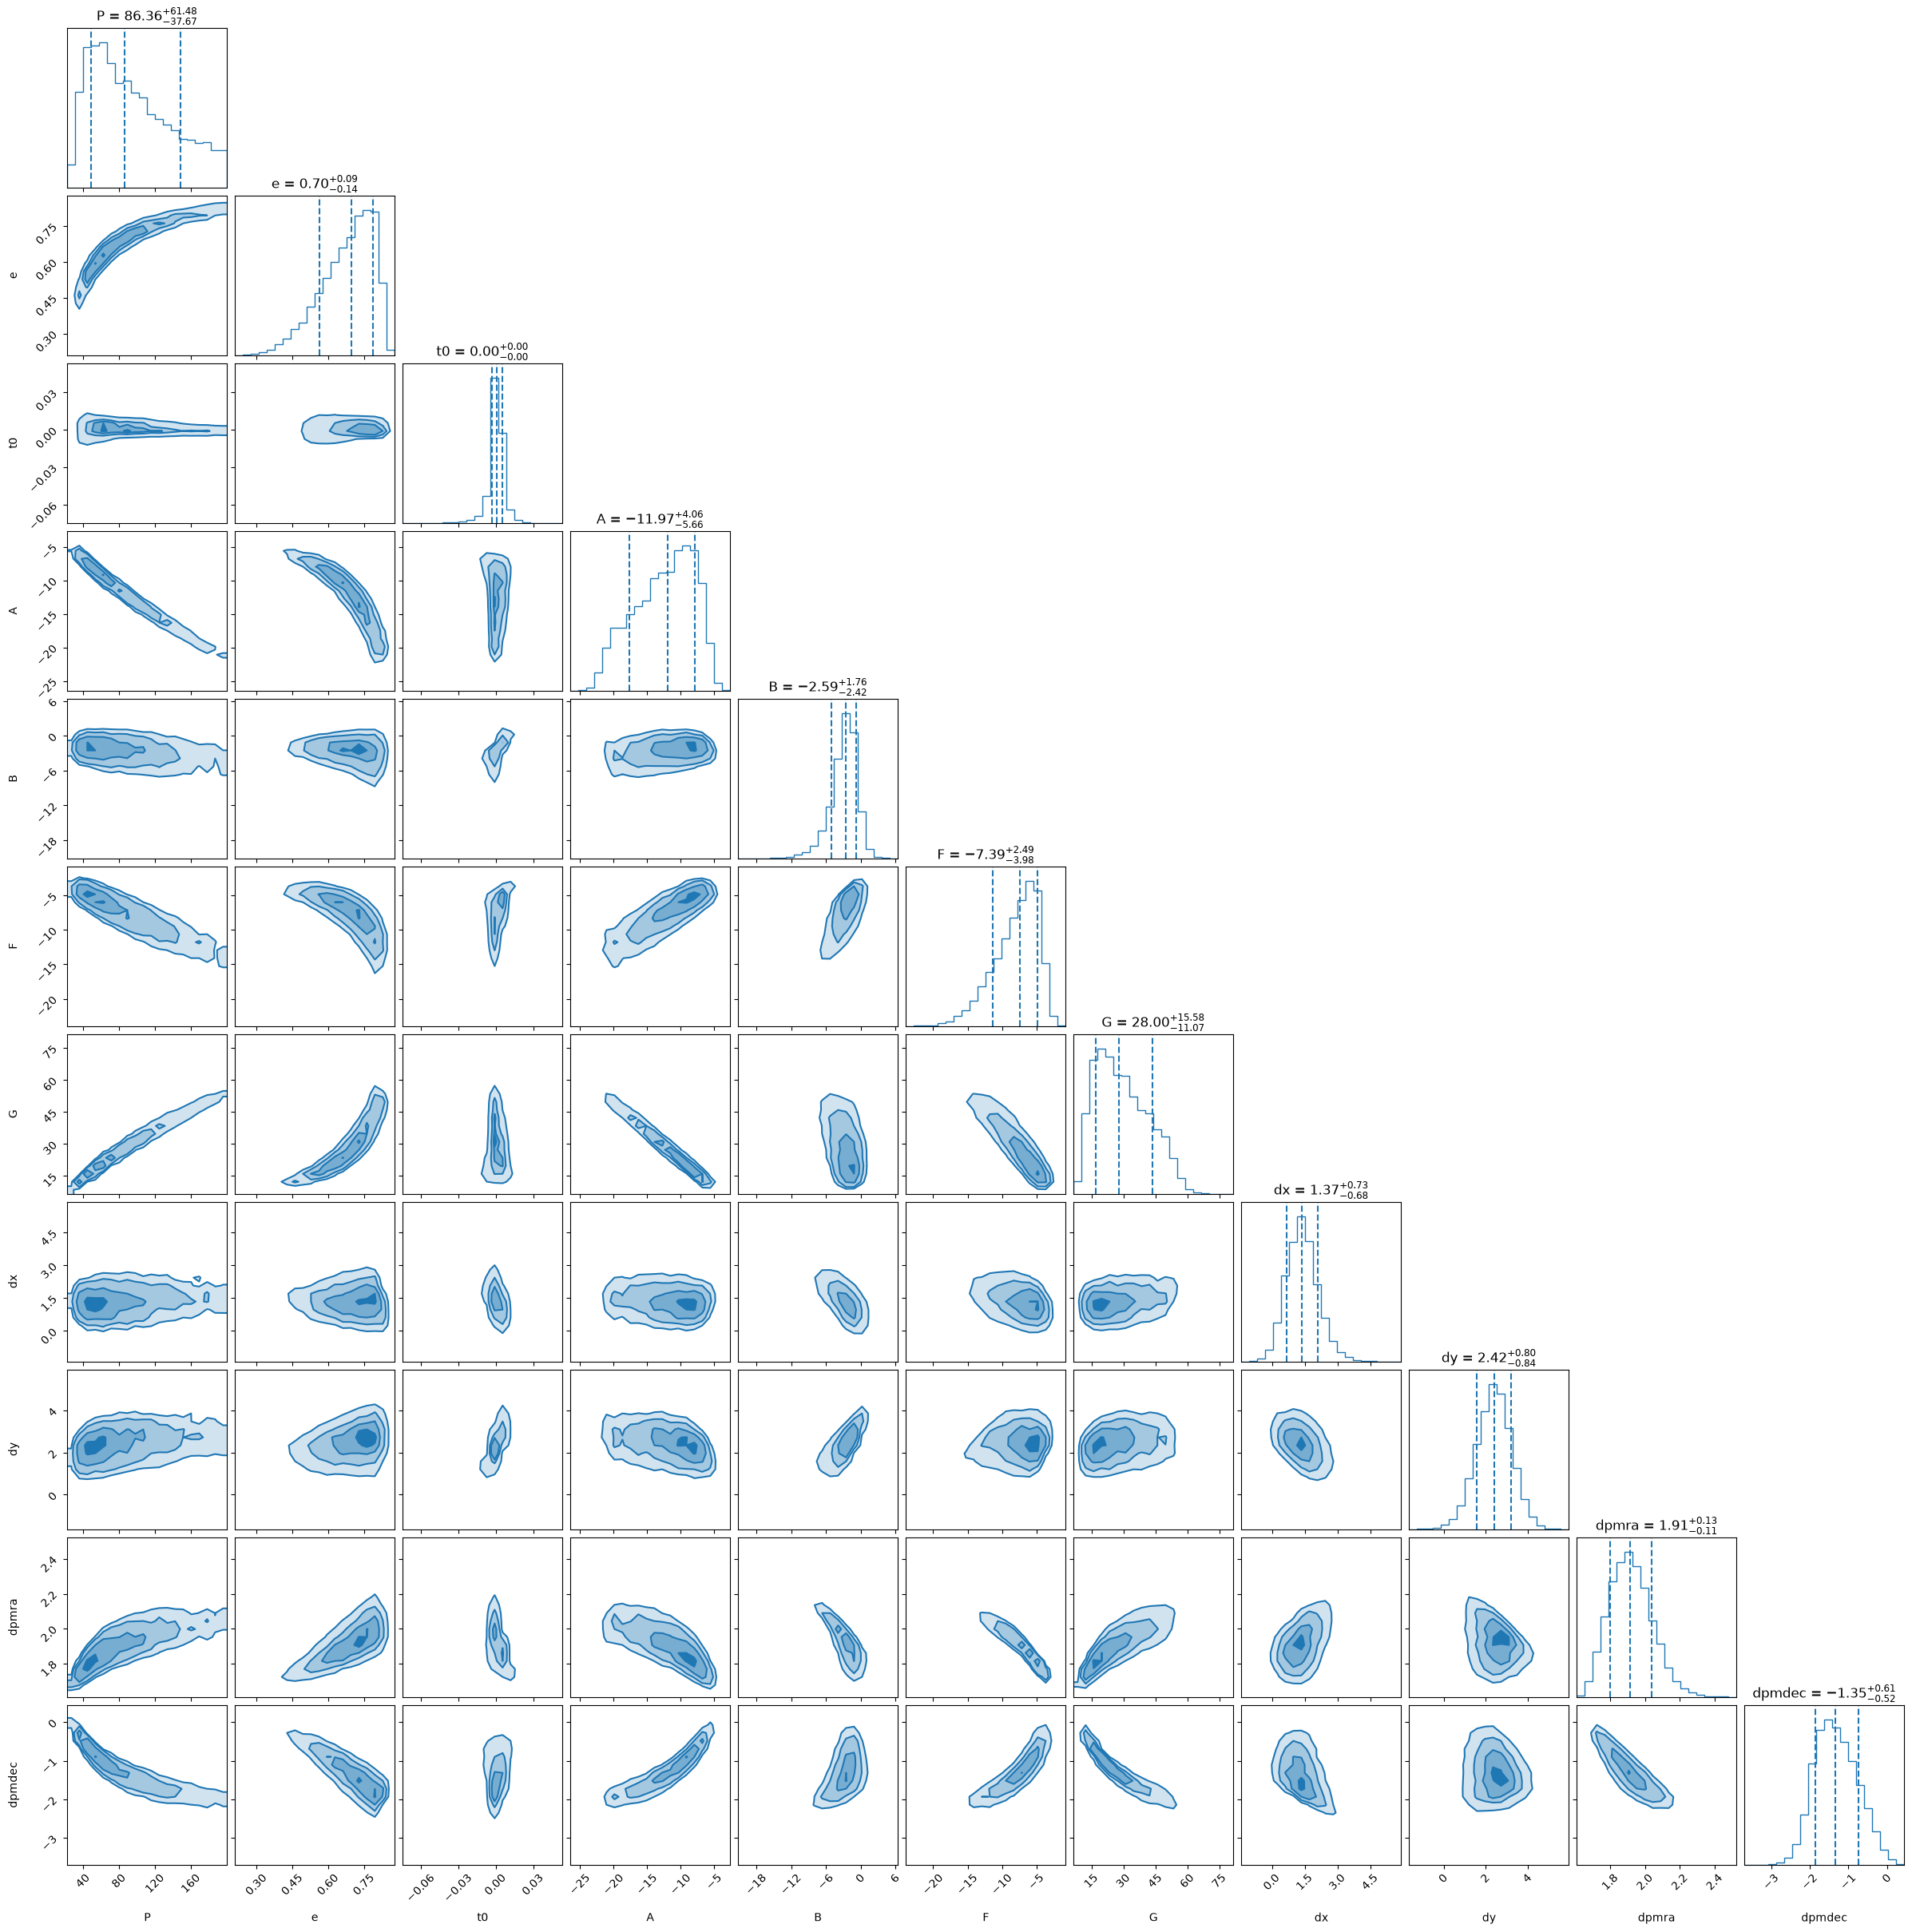

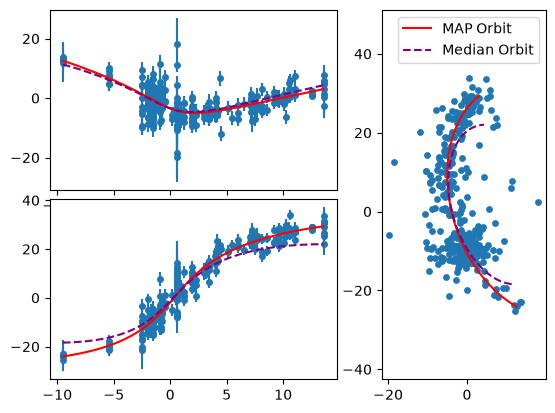

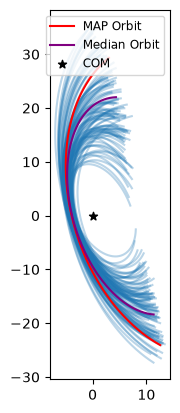

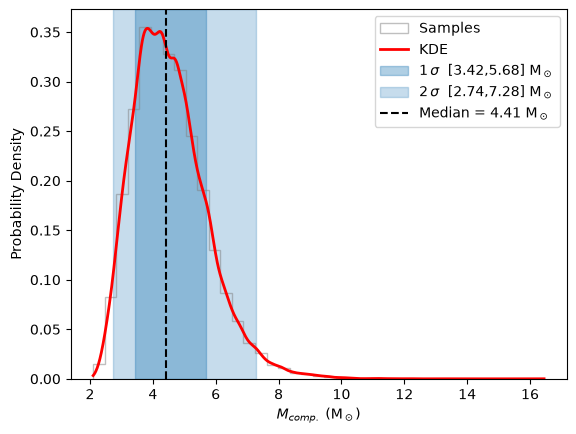

In [ ]:
plots.all_plots(results=results2,data=fit_data,priors=priors,m1=m_vis)